# Flight Features EDA and Modeling Dataset Build

This notebook analyzes the current `../flight_features.csv` export and creates `../data/flight_features_cleaned_for_modeling.csv` for model training.

The new dataset includes historical rolling delay features:

- `route_avg_delay_7d`, `route_avg_delay_30d`, `route_delay_rate_7d`
- `airline_avg_delay_7d`, `airline_avg_delay_30d`, `airline_delay_rate_7d`
- `dep_airport_avg_delay_7d`, `dep_airport_avg_delay_30d`, `dep_airport_delay_rate_7d`

These features are retained because they are historical aggregates. They are valid only if the upstream pipeline computes them from information available before the prediction time.


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import pointbiserialr

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

def find_project_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    candidates.extend(path for path in cwd.iterdir() if path.is_dir())
    for candidate in candidates:
        if (candidate / "flight_features.csv").exists() and (candidate / "notebooks").exists():
            return candidate
    return cwd.parent if cwd.name == "notebooks" else cwd


PROJECT_DIR = find_project_dir()
RAW_PATH = PROJECT_DIR / "flight_features.csv"
OUTPUT_DIR = PROJECT_DIR / "media" / "eda"
DATA_DIR = PROJECT_DIR / "data"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

if not RAW_PATH.exists():
    raise FileNotFoundError(f"Raw feature export not found: {RAW_PATH}")

df_raw = pd.read_csv(RAW_PATH)
print(f"Raw dataset: {df_raw.shape[0]:,} rows x {df_raw.shape[1]:,} columns")
print("Source:", RAW_PATH.resolve())


Raw dataset: 15,587 rows x 63 columns
Source: C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\flight_features.csv


## 1. Initial Data Inspection

In [2]:
print("Column dtypes:")
print(df_raw.dtypes.to_string())

print("\nSample rows:")
display(df_raw.head(3).T)

print("\nNumeric summary:")
display(df_raw.describe().T)


Column dtypes:
flight_iata                    object
dep_scheduled_utc              object
dep_iata                       object
arr_iata                       object
airline_iata                   object
airline_icao                   object
status                         object
dep_terminal                   object
flight_number                   int64
dep_delay_min                 float64
is_delayed                     object
hour_of_day                     int64
day_of_week                     int64
month                           int64
season                         object
is_weekend                     object
dep_airport_type               object
dep_latitude                  float64
dep_longitude                 float64
dep_elevation_ft              float64
dep_iso_country                object
dep_iso_region                 object
dep_municipality               object
dep_scheduled_service          object
arr_airport_type               object
arr_latitude                  float

,0,1,2
flight_iata,SU1942,TK352,KC1352
dep_scheduled_utc,2026-04-10 00:05:00+00,2026-04-10 00:40:00+00,2026-04-10 00:40:00+00
dep_iata,SVO,IST,IST
arr_iata,ALA,ALA,ALA
airline_iata,SU,TK,KC
...,...,...,...
airline_delay_rate_7d,1.0,1.0,1.0
dep_airport_avg_delay_7d,21.0,21.0,21.0
dep_airport_avg_delay_30d,21.0,21.0,21.0
dep_airport_delay_rate_7d,1.0,1.0,1.0



Numeric summary:


,count,mean,std,min,25%,50%,75%,max
flight_number,15587.0,3447.044460,3183.297063,35.00000,730.000000,1352.000000,6531.000000,9960.000000
dep_delay_min,9956.0,20.708718,36.071623,1.00000,8.000000,14.000000,24.000000,945.000000
hour_of_day,15587.0,12.526721,7.096354,0.00000,7.000000,12.000000,19.000000,23.000000
day_of_week,15587.0,3.149227,1.960225,0.00000,1.000000,3.000000,5.000000,6.000000
month,15587.0,4.251171,0.433700,4.00000,4.000000,4.000000,5.000000,5.000000
dep_latitude,15587.0,44.837894,6.999308,2.74558,43.311087,43.354267,51.027035,59.800301
dep_longitude,15587.0,69.554836,18.546575,-1.32806,68.550352,71.467094,77.042828,128.938004
dep_elevation_ft,15553.0,1275.094516,819.390441,-72.00000,595.000000,1165.000000,2234.000000,4482.000000
arr_latitude,15587.0,45.135991,6.749057,2.74558,43.354267,43.354267,51.027035,59.800301
arr_longitude,15587.0,67.879590,19.526485,-1.32806,65.592499,71.467094,77.042828,128.938004


In [3]:
BOOL_COLS = [
    "is_delayed",
    "is_weekend",
    "is_domestic",
    "is_international",
    "dep_scheduled_service",
    "arr_scheduled_service",
    "has_restriction_dep",
    "has_restriction_arr",
    "has_parachute_activity_dep",
    "has_military_exercise_dep",
    "has_runway_closure_dep",
    "has_runway_closure_arr",
    "has_airspace_restriction",
    "dep_notams_available",
    "arr_notams_available",
]

ROLLING_DELAY_COLS = [
    "route_avg_delay_7d",
    "route_avg_delay_30d",
    "route_delay_rate_7d",
    "airline_avg_delay_7d",
    "airline_avg_delay_30d",
    "airline_delay_rate_7d",
    "dep_airport_avg_delay_7d",
    "dep_airport_avg_delay_30d",
    "dep_airport_delay_rate_7d",
]
ROLLING_DELAY_COLS = [col for col in ROLLING_DELAY_COLS if col in df_raw.columns]


def normalize_bool_series(series: pd.Series) -> pd.Series:
    if series.dtype == "bool":
        return series.astype("boolean")
    if pd.api.types.is_numeric_dtype(series):
        return series.map({1: True, 0: False}).astype("boolean")
    return series.map(
        lambda value: {
            "t": True,
            "true": True,
            "1": True,
            "yes": True,
            "y": True,
            "f": False,
            "false": False,
            "0": False,
            "no": False,
            "n": False,
        }.get(str(value).strip().lower(), pd.NA)
        if pd.notna(value)
        else pd.NA
    ).astype("boolean")


df = df_raw.copy()
for col in BOOL_COLS:
    if col in df.columns:
        df[col] = normalize_bool_series(df[col])
        df[f"{col}_int"] = df[col].astype("Int8")

for col in ["dep_scheduled_utc", "updated_at"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], utc=True, errors="coerce")

print("Boolean columns normalized:", [col for col in BOOL_COLS if col in df.columns])
print("Rolling historical delay features found:", ROLLING_DELAY_COLS)


Boolean columns normalized: ['is_delayed', 'is_weekend', 'is_domestic', 'is_international', 'dep_scheduled_service', 'arr_scheduled_service', 'has_restriction_dep', 'has_restriction_arr', 'has_parachute_activity_dep', 'has_military_exercise_dep', 'has_runway_closure_dep', 'has_runway_closure_arr', 'has_airspace_restriction', 'dep_notams_available', 'arr_notams_available']
Rolling historical delay features found: ['route_avg_delay_7d', 'route_avg_delay_30d', 'route_delay_rate_7d', 'airline_avg_delay_7d', 'airline_avg_delay_30d', 'airline_delay_rate_7d', 'dep_airport_avg_delay_7d', 'dep_airport_avg_delay_30d', 'dep_airport_delay_rate_7d']


## 2. Target, Status, and Missing Values

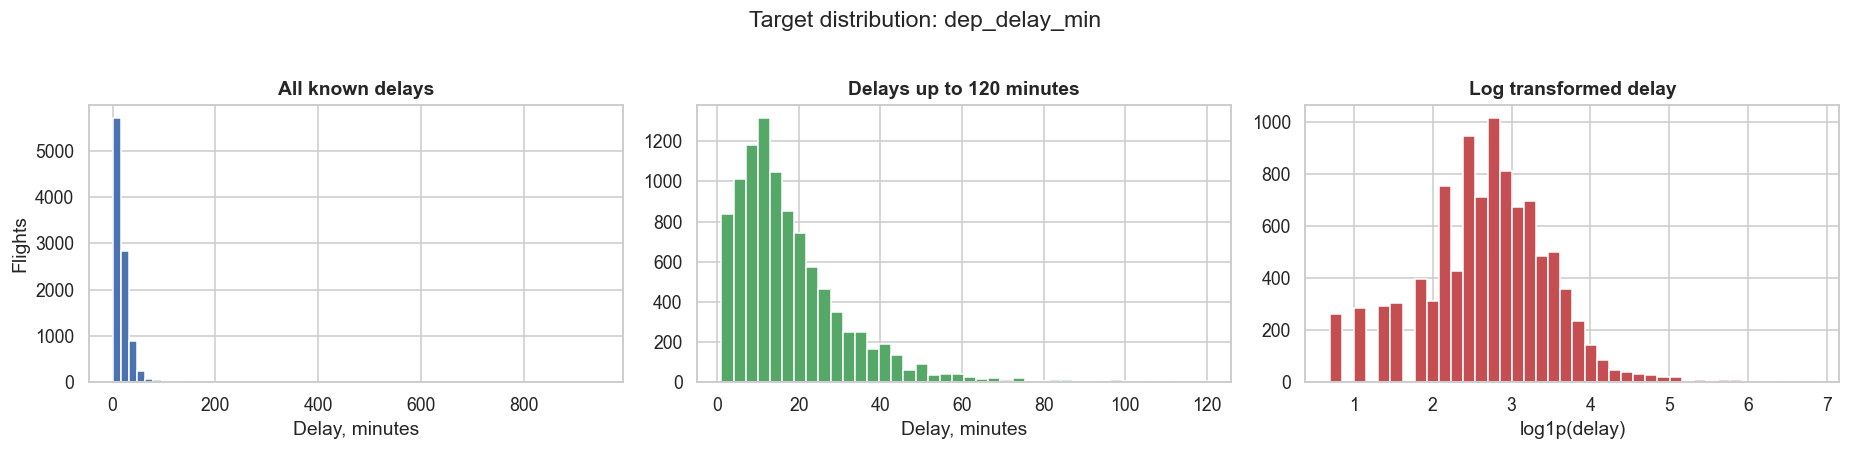

In [4]:
target_known = df.dropna(subset=["dep_delay_min"])

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle("Target distribution: dep_delay_min", y=1.02)
axes[0].hist(target_known["dep_delay_min"], bins=60, color="#4C72B0", edgecolor="white")
axes[0].set_xlabel("Delay, minutes")
axes[0].set_ylabel("Flights")
axes[0].set_title("All known delays")
axes[1].hist(target_known.loc[target_known["dep_delay_min"] <= 120, "dep_delay_min"], bins=40, color="#55A868", edgecolor="white")
axes[1].set_xlabel("Delay, minutes")
axes[1].set_title("Delays up to 120 minutes")
axes[2].hist(np.log1p(target_known["dep_delay_min"]), bins=40, color="#C44E52", edgecolor="white")
axes[2].set_xlabel("log1p(delay)")
axes[2].set_title("Log transformed delay")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_01_target_distribution.png", bbox_inches="tight")
plt.show()


Class balance for is_delayed


,count
on_time,5398
delayed,4558
missing,5631


Delayed rate among labeled rows: 45.8%


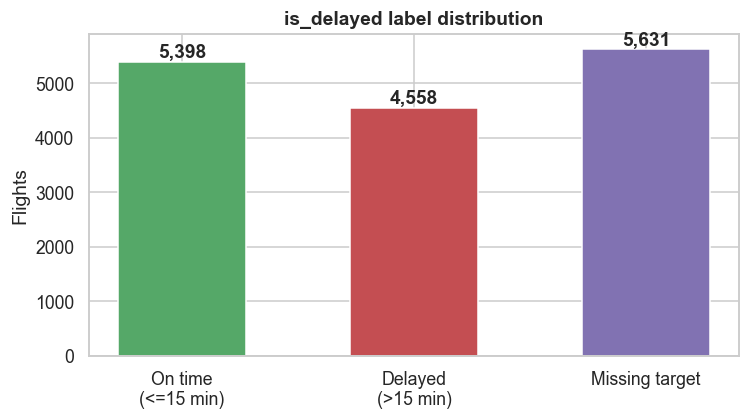

In [5]:
labeled_target = df["is_delayed"].dropna()
delayed_count = int((labeled_target == True).sum())
on_time_count = int((labeled_target == False).sum())
missing_target_count = int(df["is_delayed"].isna().sum())

print("Class balance for is_delayed")
display(pd.Series({"on_time": on_time_count, "delayed": delayed_count, "missing": missing_target_count}).to_frame("count"))
print(f"Delayed rate among labeled rows: {delayed_count / max(len(labeled_target), 1) * 100:.1f}%")

fig, ax = plt.subplots(figsize=(7, 4))
labels = ["On time\n(<=15 min)", "Delayed\n(>15 min)", "Missing target"]
values = [on_time_count, delayed_count, missing_target_count]
bars = ax.bar(labels, values, color=["#55A868", "#C44E52", "#8172B2"], edgecolor="white", width=0.55)
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{value:,}", ha="center", va="bottom", fontweight="bold")
ax.set_title("is_delayed label distribution")
ax.set_ylabel("Flights")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_02_class_balance.png", bbox_inches="tight")
plt.show()


Flight status distribution


,count
status,
active,7064
landed,5613
unknown,2867
cancelled,28
diverted,15


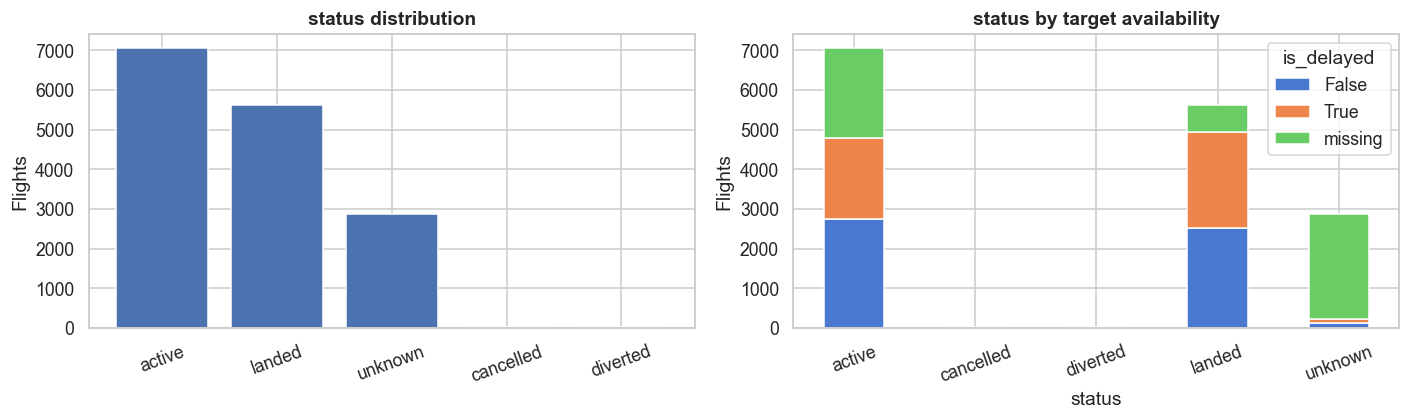

In [6]:
print("Flight status distribution")
display(df["status"].value_counts(dropna=False).to_frame("count"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
status_counts = df["status"].value_counts(dropna=False)
axes[0].bar(status_counts.index.astype(str), status_counts.values, color="#4C72B0", edgecolor="white")
axes[0].set_title("status distribution")
axes[0].set_ylabel("Flights")
axes[0].tick_params(axis="x", rotation=20)

target_status = pd.crosstab(
    df["status"].fillna("missing"),
    df["is_delayed"].astype("object").where(df["is_delayed"].notna(), "missing"),
)
target_status.plot(kind="bar", stacked=True, ax=axes[1], edgecolor="white")
axes[1].set_title("status by target availability")
axes[1].set_xlabel("status")
axes[1].set_ylabel("Flights")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="is_delayed")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_03_status_vs_delayed.png", bbox_inches="tight")
plt.show()


,missing_count,missing_pct
dep_terminal,7909,50.74
notam_max_hours_arr,6299,40.41
notam_max_hours_dep,6166,39.56
has_restriction_arr,5749,36.88
has_restriction_arr_int,5749,36.88
has_runway_closure_arr,5749,36.88
has_runway_closure_arr_int,5749,36.88
notam_active_arr,5749,36.88
notam_count_arr,5749,36.88
dep_delay_min,5631,36.13


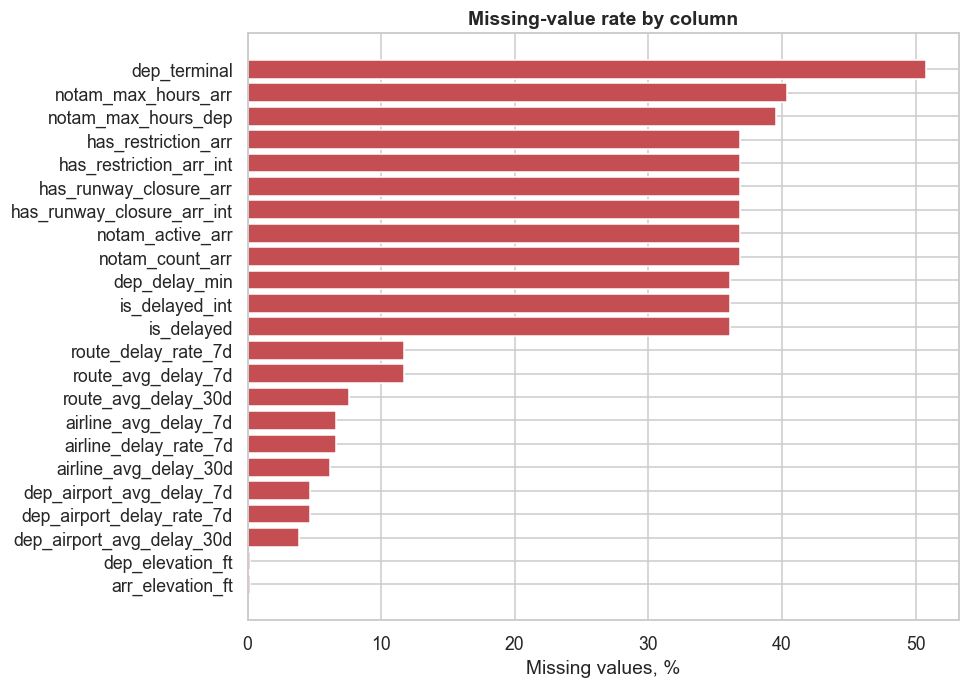

Arrival NOTAM availability vs notam_count_arr missingness


notam_count_arr,False,True,All
arr_notams_available,,,
False,0,5749,5749
True,9838,0,9838
All,9838,5749,15587


Missing target rows by status


,missing_is_delayed
status,
active,2281
cancelled,26
diverted,0
landed,683
unknown,2641


In [7]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df.loc[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)

display(missing_df)

fig, ax = plt.subplots(figsize=(9, max(4, len(missing_df) * 0.28)))
ax.barh(missing_df.index, missing_df["missing_pct"], color="#C44E52", edgecolor="white")
ax.set_xlabel("Missing values, %")
ax.set_title("Missing-value rate by column")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_04_missing_values.png", bbox_inches="tight")
plt.show()

if {"arr_notams_available", "notam_count_arr"}.issubset(df.columns):
    print("Arrival NOTAM availability vs notam_count_arr missingness")
    display(pd.crosstab(df["arr_notams_available"], df["notam_count_arr"].isna(), margins=True))

print("Missing target rows by status")
display(df.groupby("status", dropna=False)["is_delayed"].apply(lambda values: values.isna().sum()).to_frame("missing_is_delayed"))


Missing-value interpretation:

- `dep_delay_min` and `is_delayed` are missing mostly because the flight has not reached a final delay outcome yet.
- arrival-side NOTAM columns are structurally missing when arrival NOTAM coverage is unavailable.
- rolling historical delay stats can be missing for routes, airlines, or departure airports with too little prior history. Missingness indicators are retained in the cleaned dataset.
- `dep_terminal` has high structural missingness. The raw value is dropped, but a `dep_terminal_missing` flag is retained.


## 3. Time, Route, Airline, and Airport Patterns

Labeled rows: 9,956


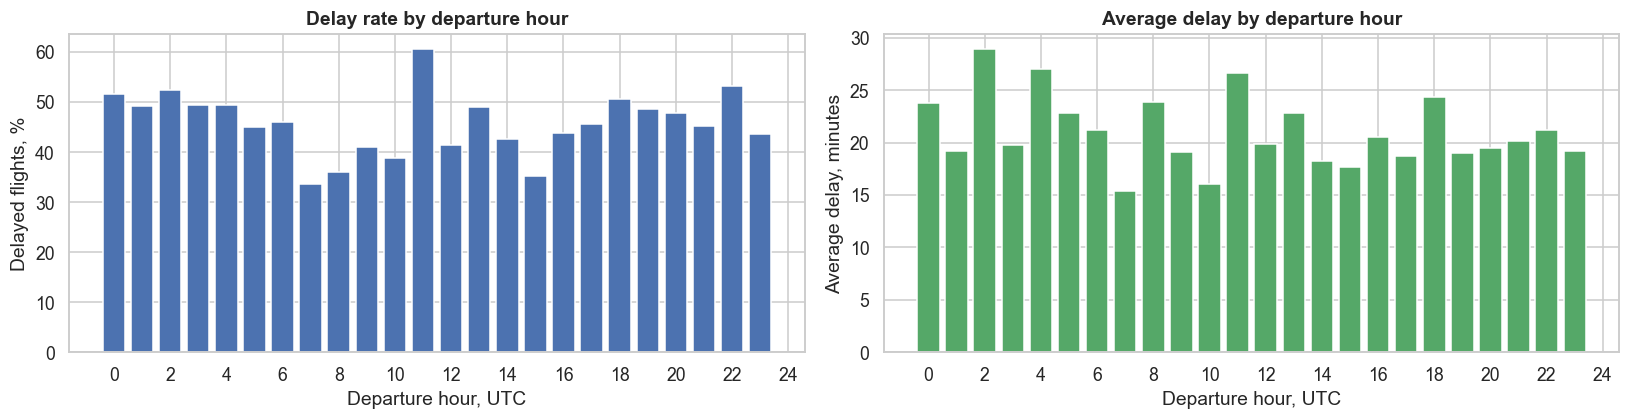

In [8]:
df_labeled = df.dropna(subset=["is_delayed", "dep_delay_min"]).copy()
df_labeled["is_delayed"] = df_labeled["is_delayed"].astype(bool)
print(f"Labeled rows: {len(df_labeled):,}")

hour_stats = df_labeled.groupby("hour_of_day").agg(
    delay_rate=("is_delayed", "mean"),
    avg_delay_min=("dep_delay_min", "mean"),
    count=("is_delayed", "count"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].bar(hour_stats["hour_of_day"], hour_stats["delay_rate"] * 100, color="#4C72B0", edgecolor="white")
axes[0].set_xlabel("Departure hour, UTC")
axes[0].set_ylabel("Delayed flights, %")
axes[0].set_title("Delay rate by departure hour")
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(2))
axes[1].bar(hour_stats["hour_of_day"], hour_stats["avg_delay_min"], color="#55A868", edgecolor="white")
axes[1].set_xlabel("Departure hour, UTC")
axes[1].set_ylabel("Average delay, minutes")
axes[1].set_title("Average delay by departure hour")
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(2))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_05_delay_by_hour.png", bbox_inches="tight")
plt.show()


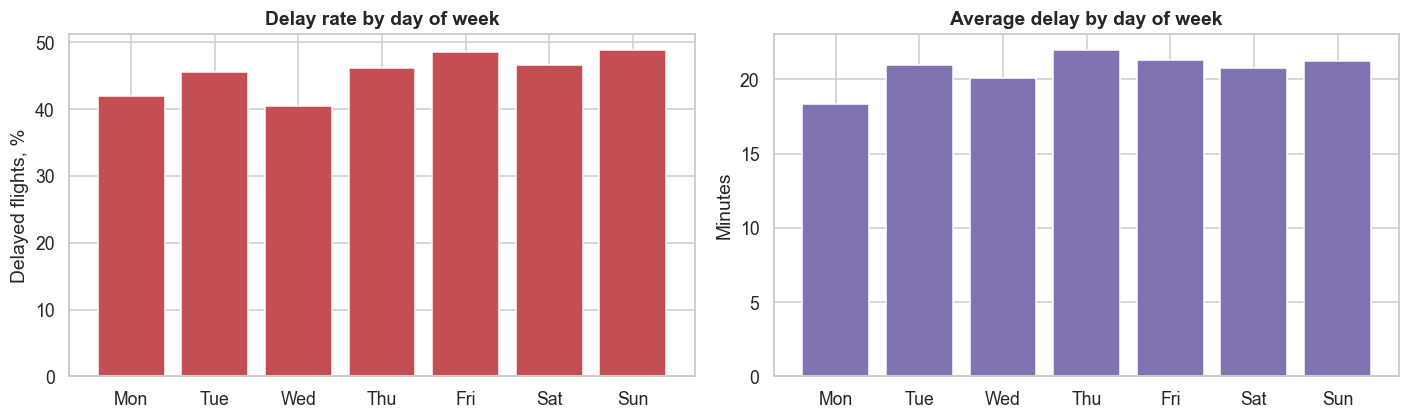

In [9]:
dow_stats = df_labeled.groupby("day_of_week").agg(
    delay_rate=("is_delayed", "mean"),
    avg_delay_min=("dep_delay_min", "mean"),
).reset_index()
dow_stats["day_name"] = dow_stats["day_of_week"].map({0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(dow_stats["day_name"], dow_stats["delay_rate"] * 100, color="#C44E52", edgecolor="white")
axes[0].set_title("Delay rate by day of week")
axes[0].set_ylabel("Delayed flights, %")
axes[1].bar(dow_stats["day_name"], dow_stats["avg_delay_min"], color="#8172B2", edgecolor="white")
axes[1].set_title("Average delay by day of week")
axes[1].set_ylabel("Minutes")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_06_delay_by_dow.png", bbox_inches="tight")
plt.show()


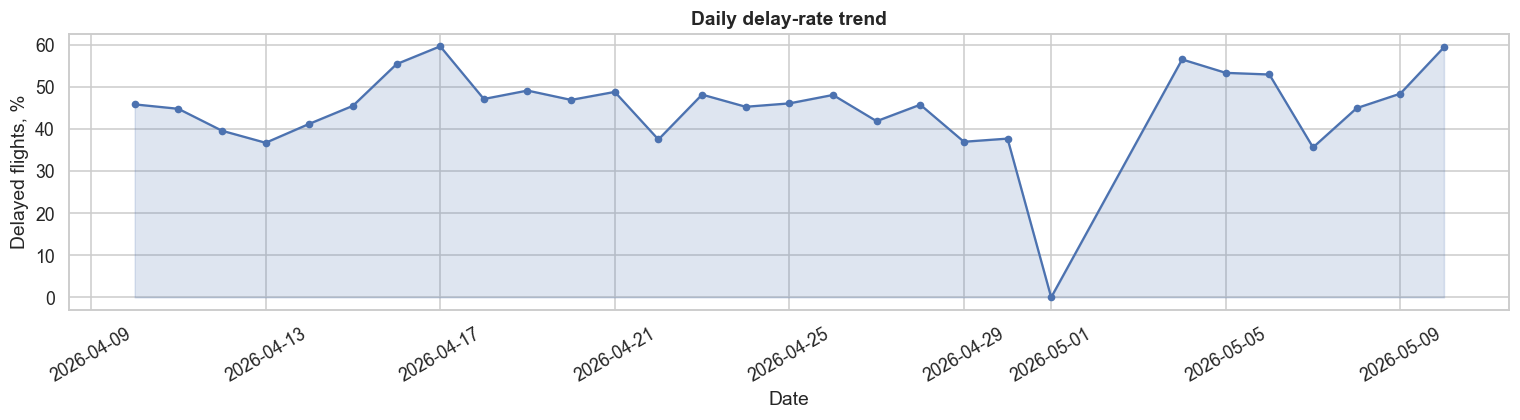

In [10]:
df_labeled["date"] = pd.to_datetime(df_labeled["dep_scheduled_utc"], utc=True).dt.floor("D")
daily = df_labeled.groupby("date").agg(delay_rate=("is_delayed", "mean"), count=("is_delayed", "count")).reset_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily["date"], daily["delay_rate"] * 100, marker="o", markersize=4, linewidth=1.5, color="#4C72B0")
ax.fill_between(daily["date"], daily["delay_rate"] * 100, 0, alpha=0.18, color="#4C72B0")
ax.set_xlabel("Date")
ax.set_ylabel("Delayed flights, %")
ax.set_title("Daily delay-rate trend")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_07_delay_timeseries.png", bbox_inches="tight")
plt.show()


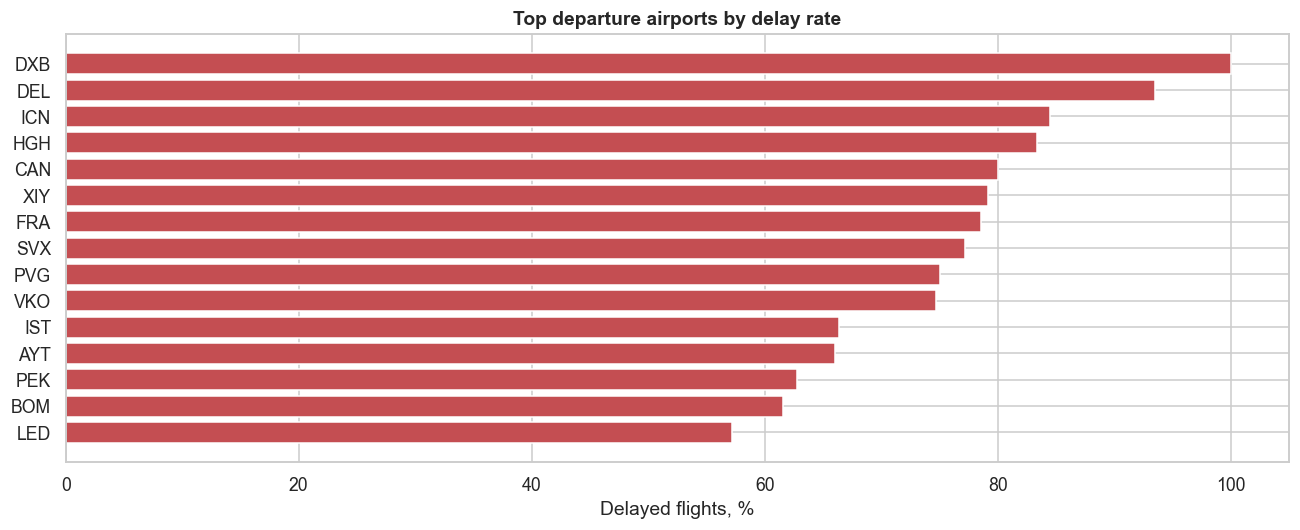

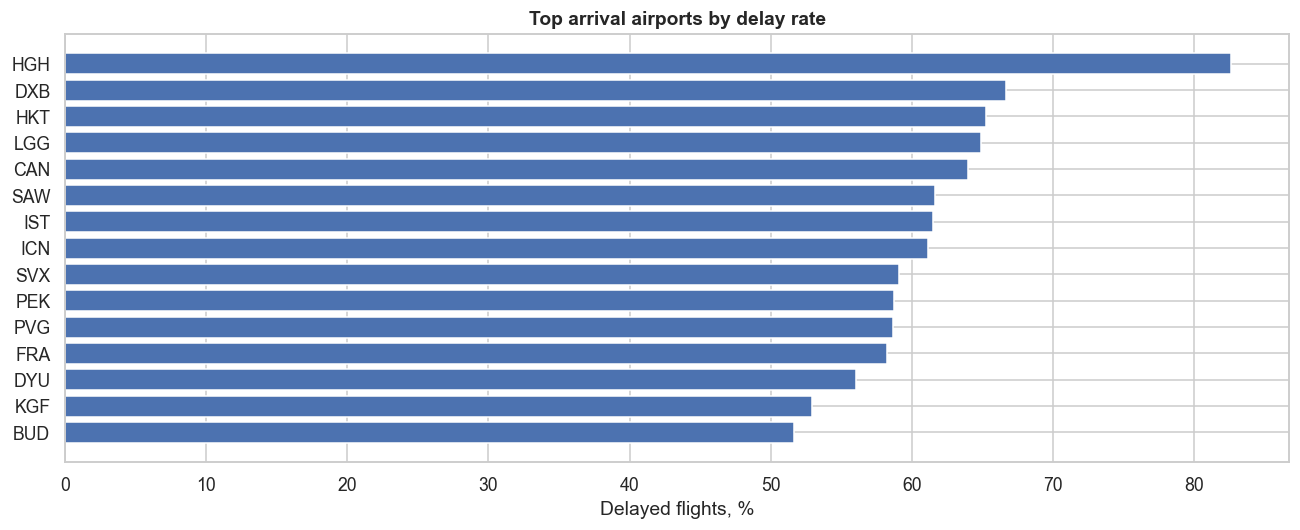

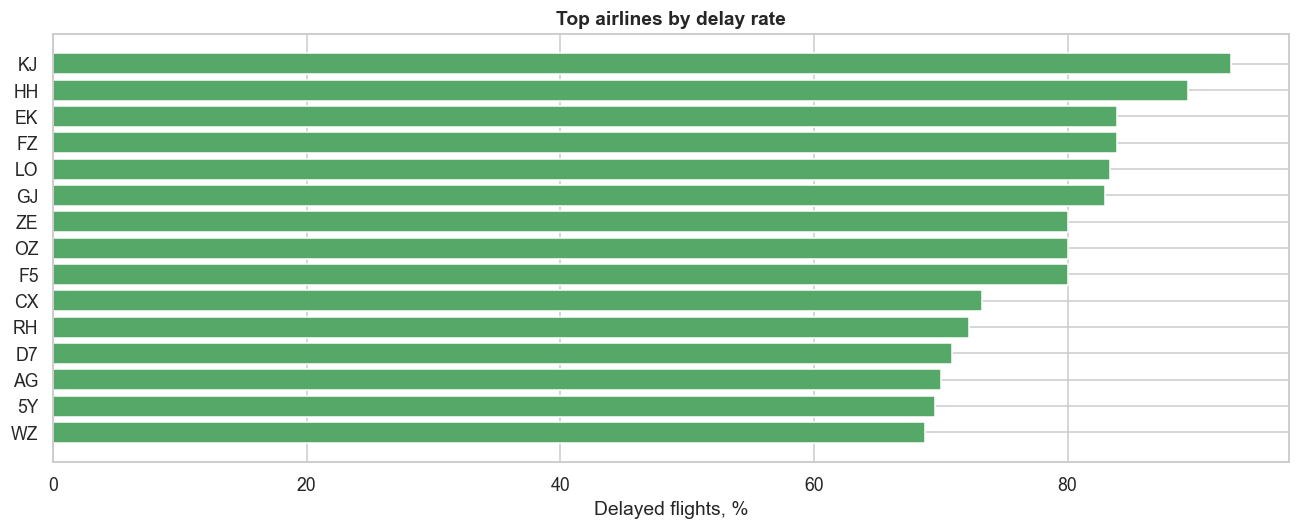

In [11]:
def top_delay_rate_plot(group_col: str, min_count: int, output_name: str, title: str, color: str) -> pd.DataFrame:
    stats_df = df_labeled.groupby(group_col).agg(
        delay_rate=("is_delayed", "mean"),
        count=("is_delayed", "count"),
        avg_delay=("dep_delay_min", "mean"),
    ).reset_index()
    stats_df = stats_df.loc[stats_df["count"] >= min_count].sort_values("delay_rate", ascending=False)
    top_df = stats_df.head(15)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh(top_df[group_col].astype(str), top_df["delay_rate"] * 100, color=color, edgecolor="white")
    ax.set_xlabel("Delayed flights, %")
    ax.set_title(title)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / output_name, bbox_inches="tight")
    plt.show()
    return stats_df

dep_stats = top_delay_rate_plot("dep_iata", 20, "eda_08_top_dep_airports.png", "Top departure airports by delay rate", "#C44E52")
arr_stats = top_delay_rate_plot("arr_iata", 20, "eda_09_top_arr_airports.png", "Top arrival airports by delay rate", "#4C72B0")
airline_stats = top_delay_rate_plot("airline_iata", 15, "eda_10_airlines.png", "Top airlines by delay rate", "#55A868")


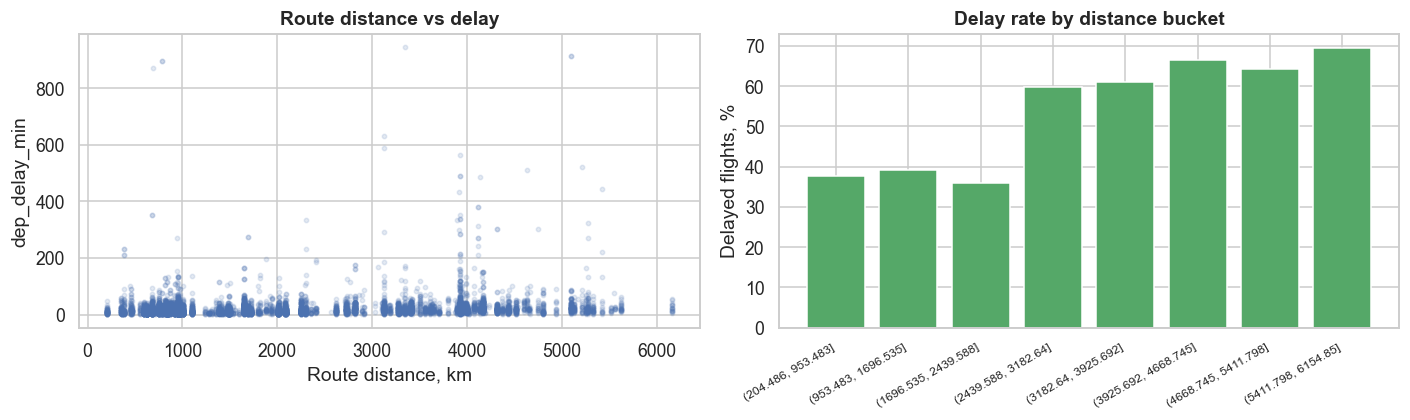

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(df_labeled["route_distance_km"], df_labeled["dep_delay_min"], alpha=0.15, s=8, color="#4C72B0")
axes[0].set_xlabel("Route distance, km")
axes[0].set_ylabel("dep_delay_min")
axes[0].set_title("Route distance vs delay")

distance_bins = pd.cut(df_labeled["route_distance_km"], bins=8)
distance_delay = df_labeled.groupby(distance_bins, observed=False)["is_delayed"].mean() * 100
axes[1].bar(range(len(distance_delay)), distance_delay.values, color="#55A868", edgecolor="white")
axes[1].set_xticks(range(len(distance_delay)))
axes[1].set_xticklabels([str(interval) for interval in distance_delay.index], rotation=30, ha="right", fontsize=8)
axes[1].set_ylabel("Delayed flights, %")
axes[1].set_title("Delay rate by distance bucket")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_11_distance_delay.png", bbox_inches="tight")
plt.show()


## 4. NOTAM, Congestion, and Rolling Historical Features

NOTAM coverage


,count
dep_notams_available,
True,9953
False,5634


,count
arr_notams_available,
True,9838
False,5749


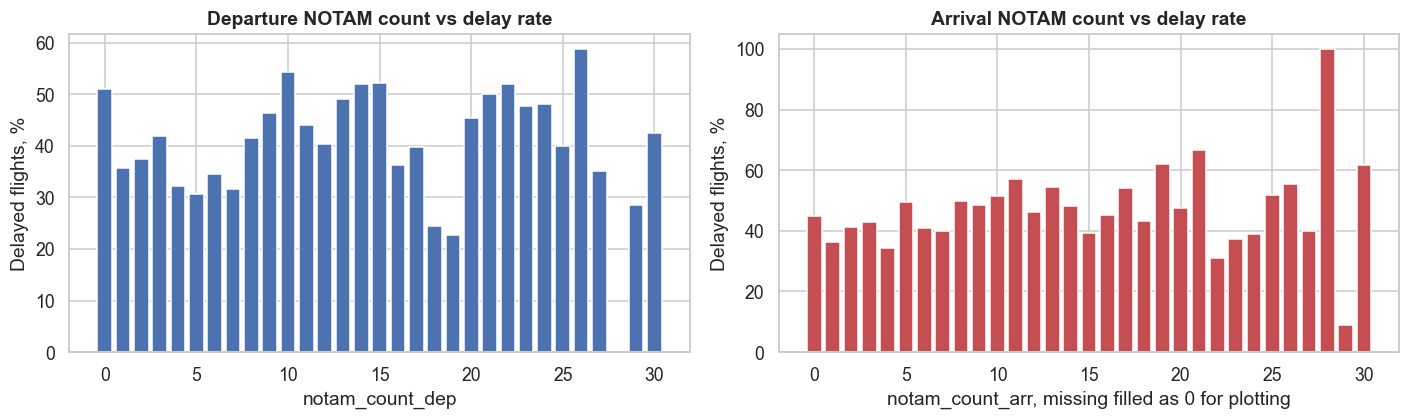

In [13]:
print("NOTAM coverage")
for col in ["dep_notams_available", "arr_notams_available"]:
    if col in df.columns:
        display(df[col].value_counts(dropna=False).to_frame("count"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
notam_dep = df_labeled.groupby("notam_count_dep")["is_delayed"].mean() * 100
notam_dep = notam_dep.loc[notam_dep.index <= 30]
axes[0].bar(notam_dep.index, notam_dep.values, color="#4C72B0", edgecolor="white")
axes[0].set_xlabel("notam_count_dep")
axes[0].set_ylabel("Delayed flights, %")
axes[0].set_title("Departure NOTAM count vs delay rate")

arr_notam = df_labeled.copy()
arr_notam["notam_count_arr_fill"] = arr_notam["notam_count_arr"].fillna(0)
notam_arr = arr_notam.groupby("notam_count_arr_fill")["is_delayed"].mean() * 100
notam_arr = notam_arr.loc[notam_arr.index <= 30]
axes[1].bar(notam_arr.index, notam_arr.values, color="#C44E52", edgecolor="white")
axes[1].set_xlabel("notam_count_arr, missing filled as 0 for plotting")
axes[1].set_ylabel("Delayed flights, %")
axes[1].set_title("Arrival NOTAM count vs delay rate")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_12_notam_counts.png", bbox_inches="tight")
plt.show()


,false_rate,true_rate
feature,,
has_restriction_dep,46.26,43.33
has_restriction_arr,45.19,47.55
has_airspace_restriction,45.56,46.32
has_runway_closure_dep,46.04,23.93
has_runway_closure_arr,46.07,34.62
has_military_exercise_dep,45.78,NaN
has_parachute_activity_dep,45.90,43.39


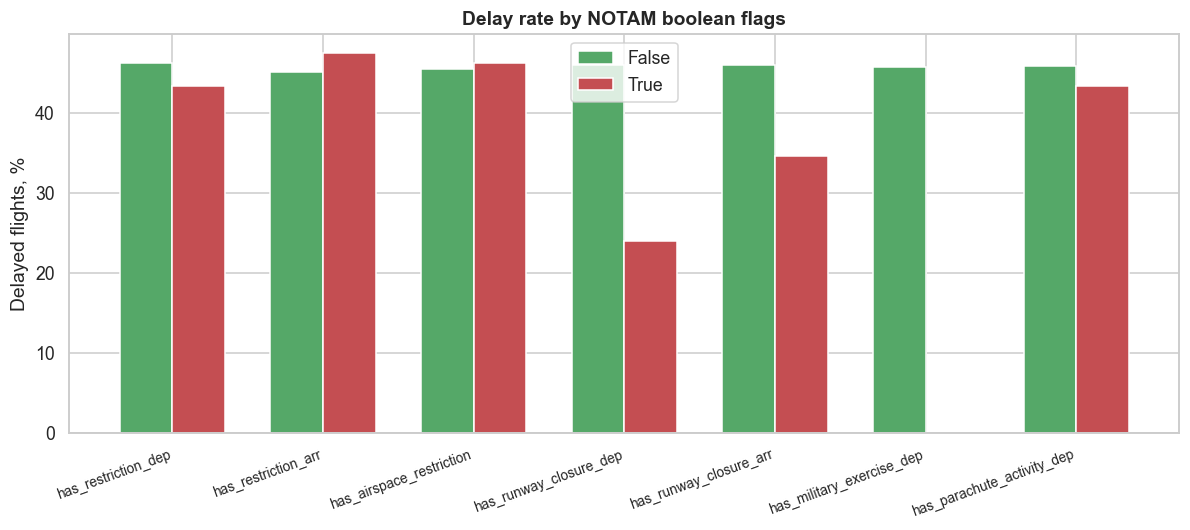

In [14]:
notam_bool_cols = [
    "has_restriction_dep",
    "has_restriction_arr",
    "has_airspace_restriction",
    "has_runway_closure_dep",
    "has_runway_closure_arr",
    "has_military_exercise_dep",
    "has_parachute_activity_dep",
]
notam_bool_cols = [col for col in notam_bool_cols if col in df_labeled.columns]
rows = []
for col in notam_bool_cols:
    grouped = df_labeled.dropna(subset=[col]).groupby(col)["is_delayed"].mean() * 100
    rows.append({"feature": col, "false_rate": grouped.get(False, np.nan), "true_rate": grouped.get(True, np.nan)})
notam_effect_df = pd.DataFrame(rows).set_index("feature")
display(notam_effect_df.round(2))

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(notam_effect_df))
width = 0.35
ax.bar(x - width / 2, notam_effect_df["false_rate"], width, label="False", color="#55A868", edgecolor="white")
ax.bar(x + width / 2, notam_effect_df["true_rate"], width, label="True", color="#C44E52", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(notam_effect_df.index, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Delayed flights, %")
ax.set_title("Delay rate by NOTAM boolean flags")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_13_notam_flags.png", bbox_inches="tight")
plt.show()


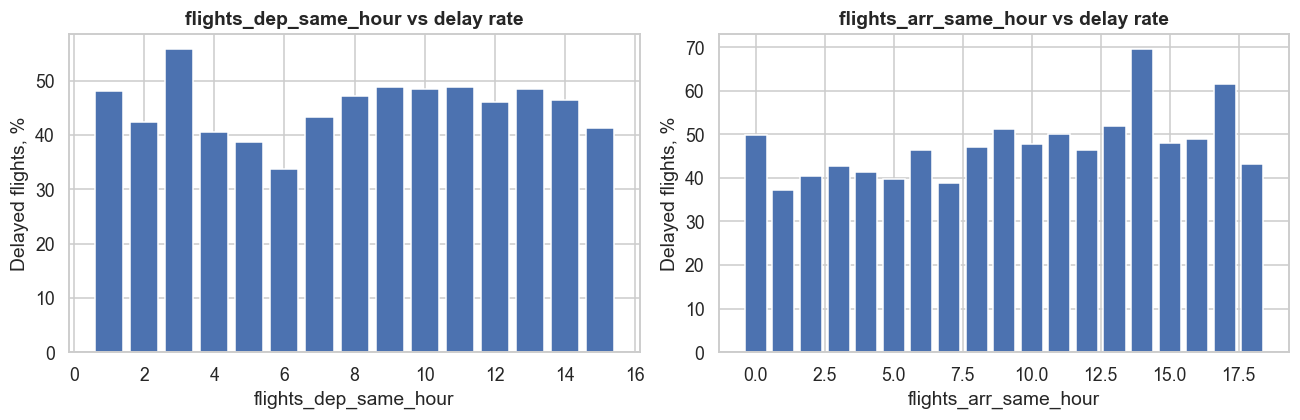

In [15]:
congestion_cols = [col for col in ["flights_dep_same_hour", "flights_arr_same_hour"] if col in df_labeled.columns]
fig, axes = plt.subplots(1, len(congestion_cols), figsize=(6 * max(len(congestion_cols), 1), 4))
if len(congestion_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, congestion_cols):
    grouped = df_labeled.groupby(col)["is_delayed"].mean() * 100
    cutoff = np.nanpercentile(grouped.index.to_numpy(dtype=float), 95)
    grouped = grouped.loc[grouped.index <= cutoff]
    ax.bar(grouped.index, grouped.values, color="#4C72B0", edgecolor="white")
    ax.set_xlabel(col)
    ax.set_ylabel("Delayed flights, %")
    ax.set_title(f"{col} vs delay rate")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_14_congestion.png", bbox_inches="tight")
plt.show()


,count,mean,std,min,25%,50%,75%,max,missing_pct
route_avg_delay_7d,13767.0,19.938,20.747,1.0,12.000,16.111,21.000,434.000,11.676
route_avg_delay_30d,14409.0,20.056,18.206,1.0,13.048,16.411,20.853,434.000,7.558
route_delay_rate_7d,13767.0,0.437,0.293,0.0,0.234,0.423,0.600,1.000,11.676
airline_avg_delay_7d,14551.0,20.489,13.750,1.0,15.201,17.493,21.682,285.500,6.647
airline_avg_delay_30d,14619.0,20.206,11.312,1.0,14.854,18.221,20.381,246.000,6.210
airline_delay_rate_7d,14551.0,0.452,0.178,0.0,0.360,0.415,0.500,1.000,6.647
dep_airport_avg_delay_7d,14856.0,19.547,15.900,1.0,14.652,17.023,18.776,434.000,4.690
dep_airport_avg_delay_30d,14981.0,19.385,12.974,1.0,15.750,16.750,18.072,284.667,3.888
dep_airport_delay_rate_7d,14856.0,0.428,0.196,0.0,0.327,0.423,0.493,1.000,4.690


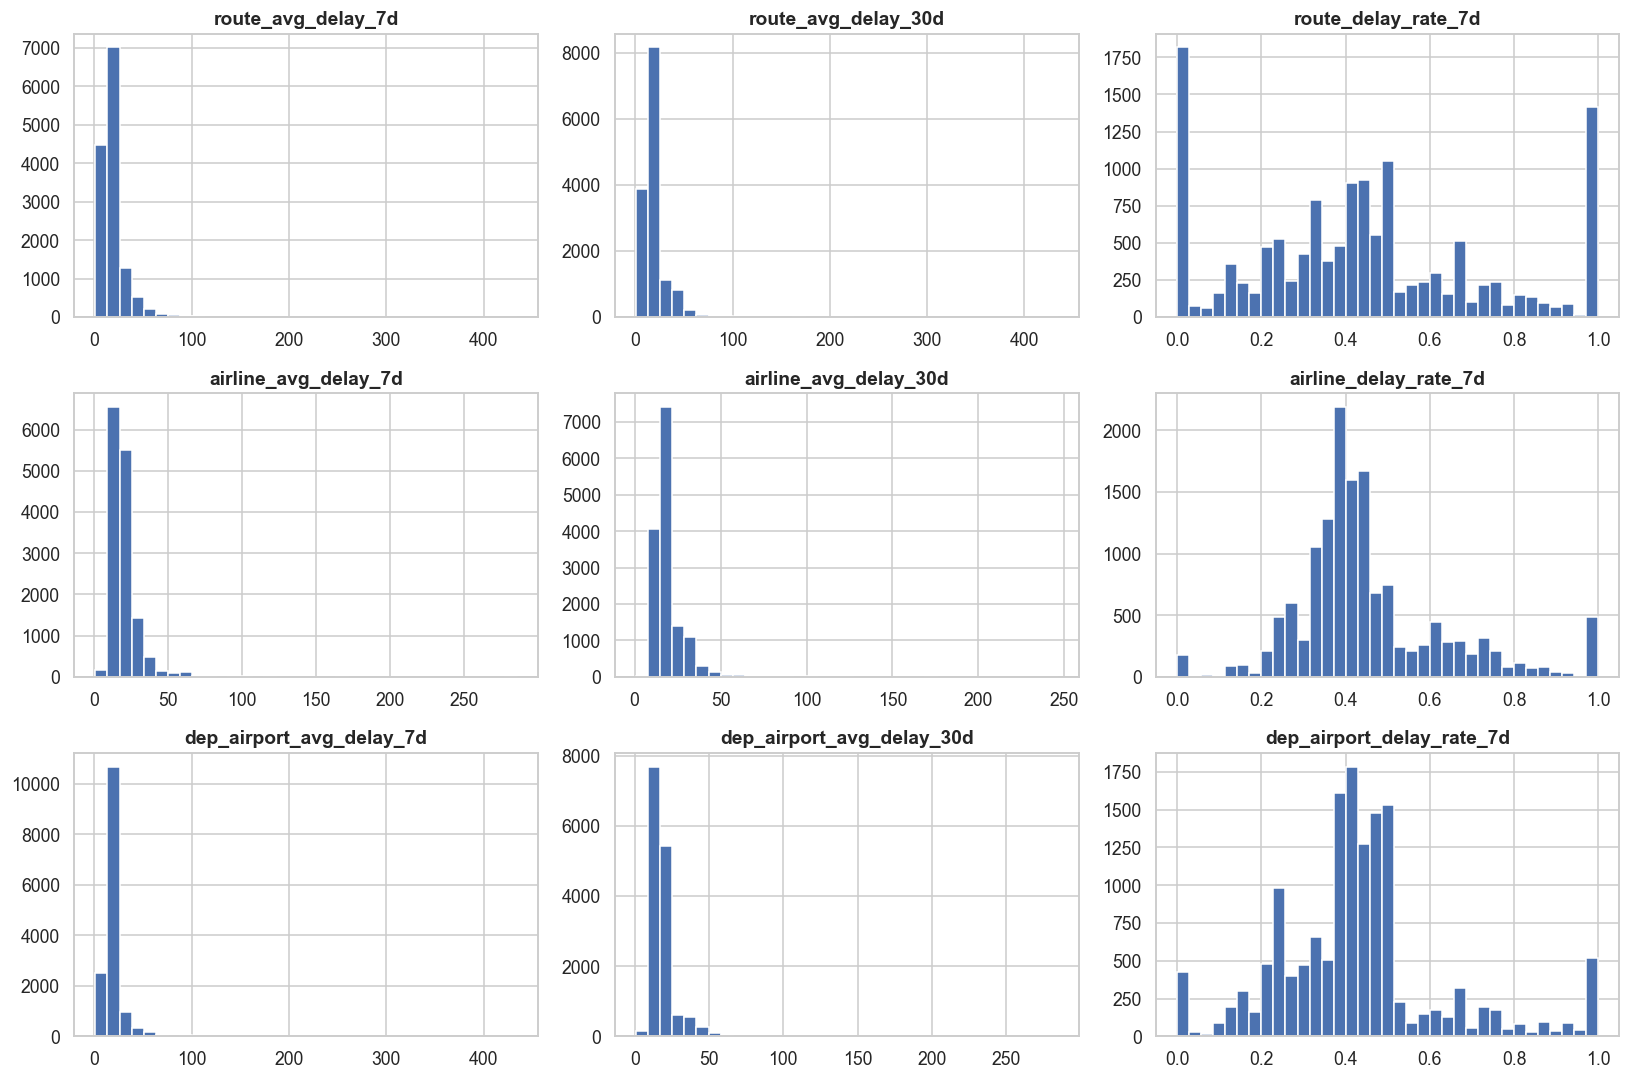

In [16]:
if not ROLLING_DELAY_COLS:
    print("No rolling historical delay features found in the raw dataset.")
else:
    rolling_summary = df[ROLLING_DELAY_COLS].describe().T
    rolling_summary["missing_pct"] = df[ROLLING_DELAY_COLS].isna().mean() * 100
    display(rolling_summary.round(3))

    fig, axes = plt.subplots(3, 3, figsize=(15, 10))
    axes = axes.ravel()
    for ax, col in zip(axes, ROLLING_DELAY_COLS):
        ax.hist(df[col].dropna(), bins=35, color="#4C72B0", edgecolor="white")
        ax.set_title(col)
    for ax in axes[len(ROLLING_DELAY_COLS):]:
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "eda_15_rolling_feature_distributions.png", bbox_inches="tight")
    plt.show()


,feature,point_biserial_with_is_delayed,p_value,pearson_with_dep_delay_min,valid_rows
2,route_delay_rate_7d,0.2500,0.0,0.1743,9071
8,dep_airport_delay_rate_7d,0.2245,0.0,0.1784,9513
1,route_avg_delay_30d,0.2171,0.0,0.2300,9342
0,route_avg_delay_7d,0.2002,0.0,0.1911,9071
5,airline_delay_rate_7d,0.1958,0.0,0.1094,9632
7,dep_airport_avg_delay_30d,0.1936,0.0,0.2423,9563
4,airline_avg_delay_30d,0.1693,0.0,0.1418,9663
6,dep_airport_avg_delay_7d,0.1652,0.0,0.1915,9513
3,airline_avg_delay_7d,0.1471,0.0,0.1220,9632


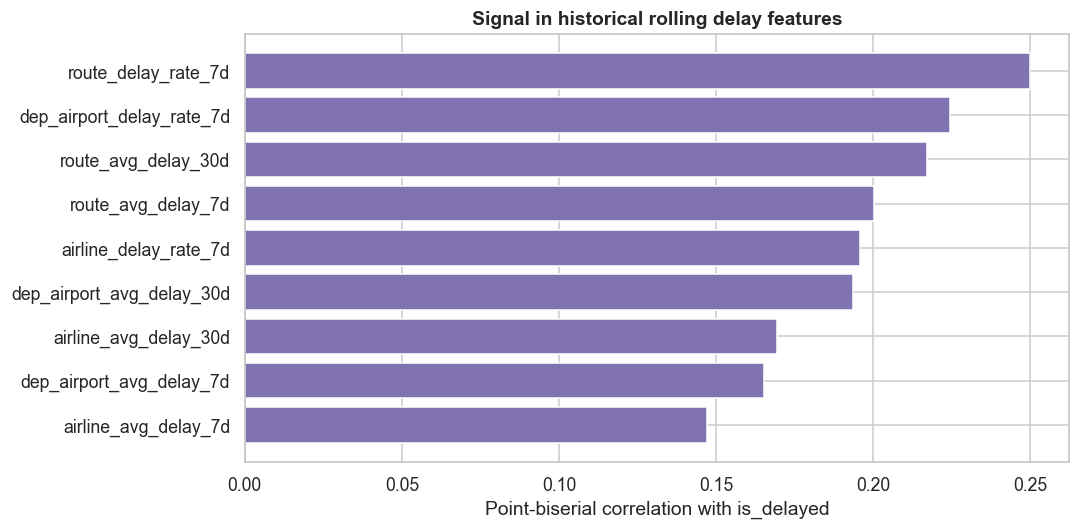

In [17]:
if ROLLING_DELAY_COLS:
    corr_rows = []
    y_binary = df_labeled["is_delayed"].astype(int)
    for col in ROLLING_DELAY_COLS:
        values = pd.to_numeric(df_labeled[col], errors="coerce")
        valid = values.notna()
        if valid.sum() < 20:
            continue
        point_corr, point_p = pointbiserialr(y_binary[valid], values[valid])
        delay_corr = values[valid].corr(df_labeled.loc[valid, "dep_delay_min"])
        corr_rows.append({
            "feature": col,
            "point_biserial_with_is_delayed": point_corr,
            "p_value": point_p,
            "pearson_with_dep_delay_min": delay_corr,
            "valid_rows": int(valid.sum()),
        })
    rolling_corr_df = pd.DataFrame(corr_rows).sort_values("point_biserial_with_is_delayed", ascending=False)
    display(rolling_corr_df.round(4))
    rolling_corr_df.to_csv(DATA_DIR / "rolling_feature_correlations.csv", index=False)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(rolling_corr_df["feature"], rolling_corr_df["point_biserial_with_is_delayed"], color="#8172B2", edgecolor="white")
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("Point-biserial correlation with is_delayed")
    ax.set_title("Signal in historical rolling delay features")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "eda_16_rolling_feature_correlations.png", bbox_inches="tight")
    plt.show()


## 5. Correlations, Cardinality, and Leakage Audit

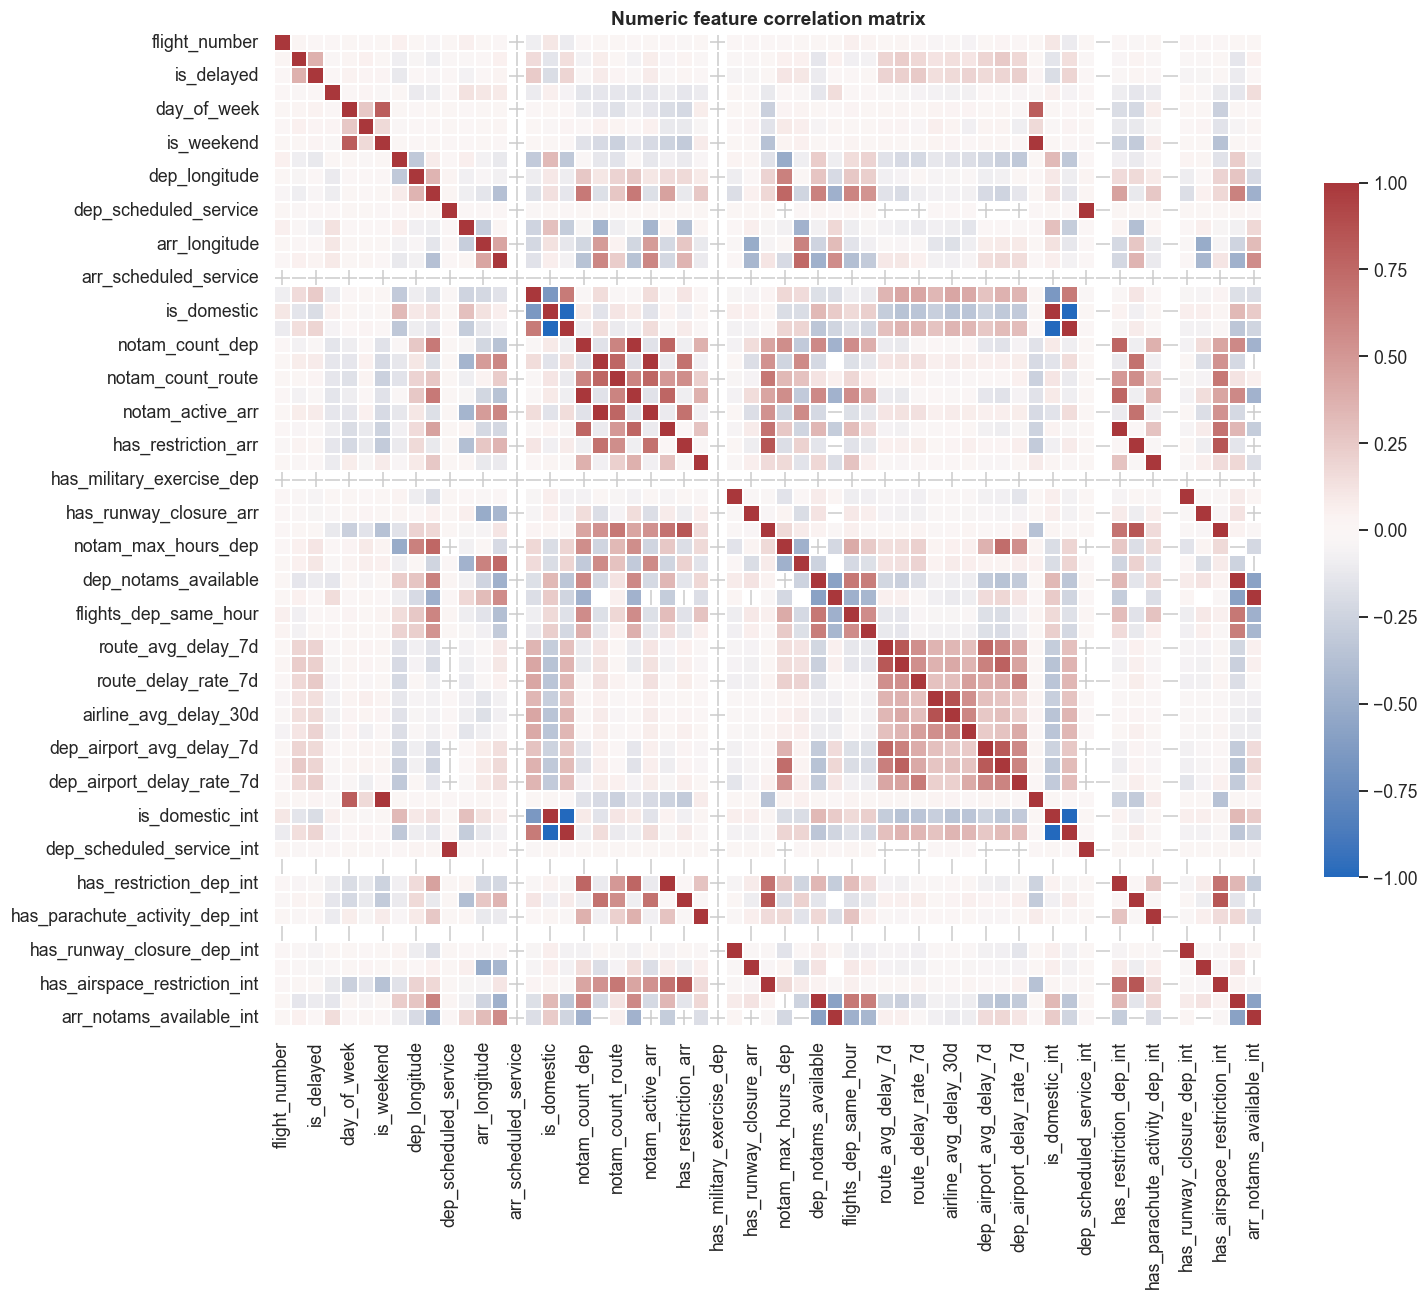

,correlation
dep_delay_min,0.371705
route_delay_rate_7d,0.249951
route_distance_km,0.237149
dep_airport_delay_rate_7d,0.224513
route_avg_delay_30d,0.217062
route_avg_delay_7d,0.200227
airline_delay_rate_7d,0.195804
dep_airport_avg_delay_30d,0.193600
is_international_int,0.191558
is_international,0.191558


In [18]:
numeric_cols = df_labeled.select_dtypes(include=["number", "bool"]).columns.tolist()
corr_cols = [col for col in numeric_cols if col != "is_delayed_int"]
corr_df = df_labeled[corr_cols].copy()
for col in corr_df.select_dtypes(include=["boolean", "bool"]).columns:
    corr_df[col] = corr_df[col].astype(float)
corr = corr_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="vlag", center=0, linewidths=0.2, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Numeric feature correlation matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_17_correlation_matrix.png", bbox_inches="tight")
plt.show()

if "is_delayed" in corr.columns:
    target_corr = corr["is_delayed"].drop("is_delayed", errors="ignore").sort_values(key=lambda s: s.abs(), ascending=False)
    display(target_corr.head(25).to_frame("correlation"))


,column,n_unique,missing_pct,top_value,top_value_pct
0,flight_iata,1326,0.00,EY5276,0.32
1,dep_iata,99,0.00,ALA,31.35
2,arr_iata,97,0.00,ALA,31.01
11,dep_municipality,96,0.00,Almaty,31.35
15,arr_municipality,94,0.00,Almaty,31.01
10,dep_iso_region,89,0.00,KZ-ALA,31.35
4,airline_icao,87,0.00,KZR,22.99
14,arr_iso_region,87,0.00,KZ-ALA,31.01
3,airline_iata,82,0.00,KC,22.99
9,dep_iso_country,39,0.00,KZ,75.54


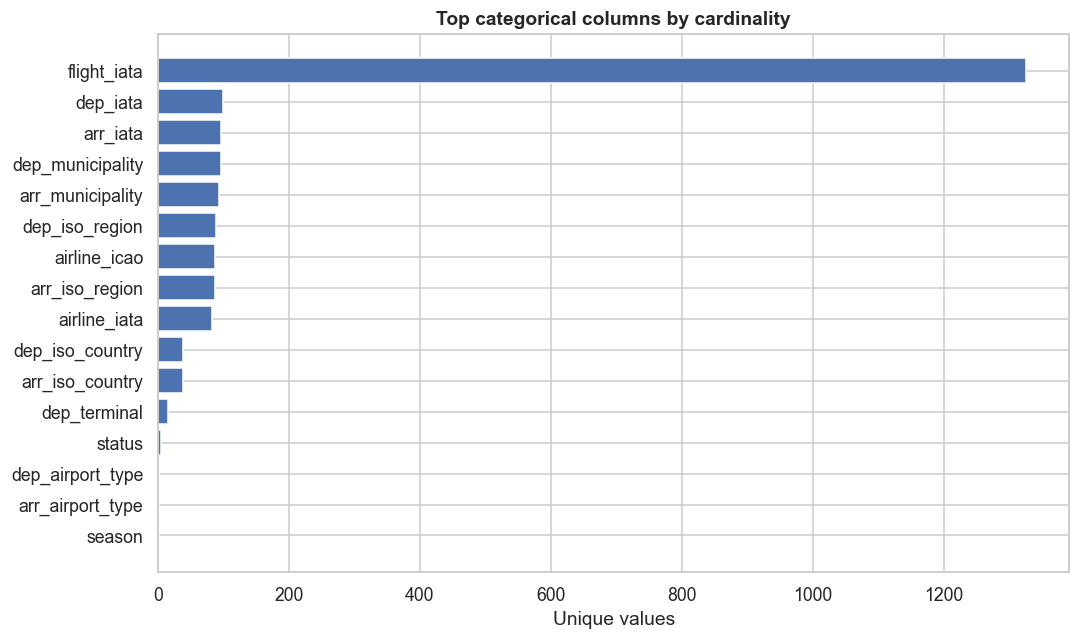

In [19]:
cat_cols = df.select_dtypes(include=["object", "category", "string"]).columns.tolist()
cardinality_rows = []
for col in cat_cols:
    value_counts = df[col].value_counts(normalize=True, dropna=True)
    cardinality_rows.append({
        "column": col,
        "n_unique": df[col].nunique(dropna=False),
        "missing_pct": round(df[col].isna().mean() * 100, 2),
        "top_value": value_counts.index[0] if len(value_counts) else None,
        "top_value_pct": round(value_counts.iloc[0] * 100, 2) if len(value_counts) else np.nan,
    })
cardinality_df = pd.DataFrame(cardinality_rows).sort_values(["n_unique", "missing_pct"], ascending=[False, False])
display(cardinality_df)
cardinality_df.to_csv(DATA_DIR / "categorical_cardinality.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 6))
top_cardinality = cardinality_df.head(20)
ax.barh(top_cardinality["column"], top_cardinality["n_unique"], color="#4C72B0", edgecolor="white")
ax.set_xlabel("Unique values")
ax.set_title("Top categorical columns by cardinality")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_18_categorical_cardinality.png", bbox_inches="tight")
plt.show()


In [30]:
leakage_audit = pd.DataFrame([
    {"column": "dep_delay_min", "decision": "TARGET only", "reason": "Regression target and direct source of the binary target."},
    {"column": "is_delayed", "decision": "TARGET only", "reason": "Binary classifier target."},
    {"column": "status", "decision": "DROP from features", "reason": "Post-event operational outcome."},
    {"column": "updated_at", "decision": "DROP from features", "reason": "Technical collection timestamp."},
    {"column": "flight_iata", "decision": "DROP from baseline features", "reason": "High-cardinality flight identifier and memorization risk."},
    {"column": "flight_number", "decision": "DROP from baseline features", "reason": "Identifier-like schedule feature."},
    {"column": "airline_icao", "decision": "DROP if airline_iata exists", "reason": "Duplicate airline representation."},
    {"column": "dep_scheduled_utc", "decision": "SPLIT ONLY", "reason": "Used for chronological split, not as a raw model feature."},
    {"column": "dep_terminal", "decision": "DROP raw value", "reason": "High structural missingness; keep only a missingness flag."},
    {"column": "rolling historical delay features", "decision": "KEEP", "reason": "Allowed only when computed from prior historical windows, never from future target data."},
])
display(leakage_audit)
leakage_audit.to_csv(DATA_DIR / "leakage_audit_table.csv", index=False)


,column,decision,reason
0,dep_delay_min,TARGET only,Regression target and direct source of the bin...
1,is_delayed,TARGET only,Binary classifier target.
2,status,DROP from features,Post-event operational outcome.
3,updated_at,DROP from features,Technical collection timestamp.
4,flight_iata,DROP from baseline features,High-cardinality flight identifier and memoriz...
5,flight_number,DROP from baseline features,Identifier-like schedule feature.
6,airline_icao,DROP if airline_iata exists,Duplicate airline representation.
7,dep_scheduled_utc,SPLIT ONLY,"Used for chronological split, not as a raw mod..."
8,dep_terminal,DROP raw value,High structural missingness; keep only a missi...
9,rolling historical delay features,KEEP,Allowed only when computed from prior historic...


## 6. Temporal Split Diagnostics

In [21]:
df_time = df_labeled.sort_values("dep_scheduled_utc").copy()
split_idx = int(len(df_time) * 0.8)
eda_train = df_time.iloc[:split_idx].copy()
eda_test = df_time.iloc[split_idx:].copy()
split_date = eda_test["dep_scheduled_utc"].min()

split_summary = pd.DataFrame({
    "split": ["eda_train", "eda_test"],
    "rows": [len(eda_train), len(eda_test)],
    "delay_rate": [eda_train["is_delayed"].mean(), eda_test["is_delayed"].mean()],
    "avg_delay_min": [eda_train["dep_delay_min"].mean(), eda_test["dep_delay_min"].mean()],
    "median_delay_min": [eda_train["dep_delay_min"].median(), eda_test["dep_delay_min"].median()],
})
print(f"Chronological split point: {split_date}")
display(split_summary.round(3))

numeric_cols_for_drift = [
    "route_distance_km",
    "hour_of_day",
    "day_of_week",
    "notam_count_dep",
    "notam_count_arr",
    "notam_count_route",
    "notam_active_dep",
    "notam_active_arr",
    "notam_max_hours_dep",
    "notam_max_hours_arr",
    "flights_dep_same_hour",
    "flights_arr_same_hour",
] + ROLLING_DELAY_COLS
numeric_cols_for_drift = [col for col in numeric_cols_for_drift if col in df_time.columns]

drift_rows = []
for col in numeric_cols_for_drift:
    train_values = pd.to_numeric(eda_train[col], errors="coerce").dropna()
    test_values = pd.to_numeric(eda_test[col], errors="coerce").dropna()
    if len(train_values) == 0 or len(test_values) == 0:
        continue
    ks_stat, ks_p = stats.ks_2samp(train_values, test_values)
    drift_rows.append({
        "feature": col,
        "train_mean": train_values.mean(),
        "test_mean": test_values.mean(),
        "mean_diff": test_values.mean() - train_values.mean(),
        "train_median": train_values.median(),
        "test_median": test_values.median(),
        "ks_stat": ks_stat,
        "ks_pvalue": ks_p,
    })
drift_df = pd.DataFrame(drift_rows).sort_values("ks_stat", ascending=False)
display(drift_df.round(4))
drift_df.to_csv(DATA_DIR / "temporal_numeric_drift.csv", index=False)


Chronological split point: 2026-04-29 18:55:00+00:00


,split,rows,delay_rate,avg_delay_min,median_delay_min
0,eda_train,7964,0.455,20.051,14.0
1,eda_test,1992,0.468,23.336,15.0


,feature,train_mean,test_mean,mean_diff,train_median,test_median,ks_stat,ks_pvalue
7,notam_active_arr,9.2466,10.9684,1.7218,6.0000,11.0000,0.3544,0.0000
4,notam_count_arr,9.2466,10.9684,1.7218,6.0000,11.0000,0.3544,0.0000
5,notam_count_route,12.3262,14.0045,1.6783,11.0000,12.0000,0.3224,0.0000
2,day_of_week,3.0187,4.1034,1.0847,3.0000,4.0000,0.3152,0.0000
20,dep_airport_delay_rate_7d,0.4566,0.4147,-0.0419,0.4472,0.3868,0.2510,0.0000
16,airline_avg_delay_30d,19.3571,20.2142,0.8571,16.7600,18.5895,0.2509,0.0000
18,dep_airport_avg_delay_7d,19.5511,20.3771,0.8260,17.5150,17.2979,0.2420,0.0000
17,airline_delay_rate_7d,0.4639,0.4306,-0.0333,0.4302,0.3891,0.2351,0.0000
6,notam_active_dep,6.4223,6.8685,0.4462,3.0000,7.0000,0.1985,0.0000
3,notam_count_dep,6.4223,6.8685,0.4462,3.0000,7.0000,0.1985,0.0000


In [22]:
cat_cols_for_shift = ["dep_iata", "arr_iata", "airline_iata", "dep_iso_country", "arr_iso_country", "is_domestic", "is_international"]
cat_cols_for_shift = [col for col in cat_cols_for_shift if col in df_time.columns]
shift_rows = []
for col in cat_cols_for_shift:
    train_dist = eda_train[col].value_counts(normalize=True, dropna=False)
    test_dist = eda_test[col].value_counts(normalize=True, dropna=False)
    all_categories = train_dist.index.union(test_dist.index)
    train_dist = train_dist.reindex(all_categories, fill_value=0)
    test_dist = test_dist.reindex(all_categories, fill_value=0)
    unseen_in_train = set(test_dist[test_dist > 0].index) - set(train_dist[train_dist > 0].index)
    shift_rows.append({
        "feature": col,
        "n_train_categories": int((train_dist > 0).sum()),
        "n_test_categories": int((test_dist > 0).sum()),
        "unseen_categories_in_test": len(unseen_in_train),
        "total_variation_distance": 0.5 * np.abs(train_dist - test_dist).sum(),
    })
shift_df = pd.DataFrame(shift_rows).sort_values("total_variation_distance", ascending=False)
display(shift_df.round(4))
shift_df.to_csv(DATA_DIR / "temporal_categorical_shift.csv", index=False)


,feature,n_train_categories,n_test_categories,unseen_categories_in_test,total_variation_distance
0,dep_iata,89,80,3,0.0756
2,airline_iata,73,62,3,0.0636
3,dep_iso_country,37,31,0,0.0599
1,arr_iata,87,81,2,0.0550
5,is_domestic,2,2,0,0.0484
6,is_international,2,2,0,0.0484
4,arr_iso_country,35,33,1,0.0214


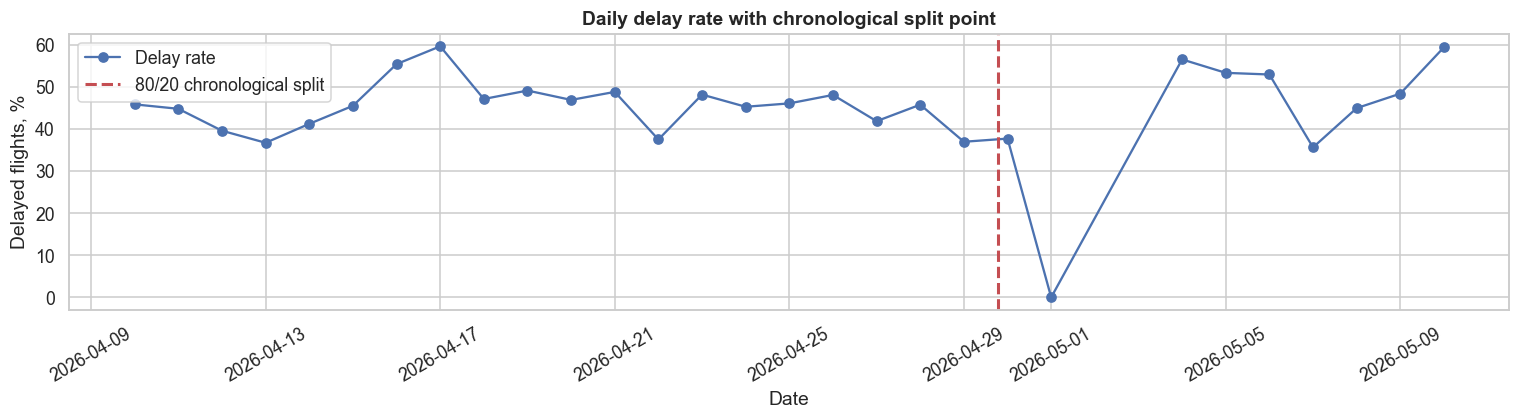

In [23]:
daily_split = (
    df_time.assign(date=df_time["dep_scheduled_utc"].dt.floor("D"))
    .groupby("date")
    .agg(delay_rate=("is_delayed", "mean"), count=("is_delayed", "count"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_split["date"], daily_split["delay_rate"] * 100, marker="o", linewidth=1.5, color="#4C72B0", label="Delay rate")
ax.axvline(split_date, color="#C44E52", linestyle="--", linewidth=2, label="80/20 chronological split")
ax.set_xlabel("Date")
ax.set_ylabel("Delayed flights, %")
ax.set_title("Daily delay rate with chronological split point")
ax.tick_params(axis="x", rotation=30)
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_19_temporal_split_target_rate.png", bbox_inches="tight")
plt.show()


## 7. Build the Cleaned Modeling Dataset

In [24]:
df_model = df.copy()

before = len(df_model)
df_model = df_model.dropna(subset=["dep_delay_min", "is_delayed"]).copy()
print(f"Drop rows without target: {before:,} -> {len(df_model):,}")

excluded_statuses = ["cancelled", "diverted"]
before = len(df_model)
df_model = df_model.loc[~df_model["status"].isin(excluded_statuses)].copy()
print(f"Remove statuses {excluded_statuses}: {before:,} -> {len(df_model):,}")

df_model["dep_delay_min"] = pd.to_numeric(df_model["dep_delay_min"], errors="coerce")
df_model = df_model.loc[df_model["dep_delay_min"].notna()].copy()
df_model["is_delayed"] = (df_model["dep_delay_min"] > 15).astype(int)

df_model["dep_scheduled_utc"] = pd.to_datetime(df_model["dep_scheduled_utc"], utc=True, errors="coerce")
if df_model["dep_scheduled_utc"].isna().any():
    raise ValueError("dep_scheduled_utc contains invalid timestamps after parsing.")

df_model["dep_hour"] = df_model["dep_scheduled_utc"].dt.hour
df_model["dep_dayofweek"] = df_model["dep_scheduled_utc"].dt.dayofweek
df_model["dep_day"] = df_model["dep_scheduled_utc"].dt.day
df_model["dep_month"] = df_model["dep_scheduled_utc"].dt.month
df_model["dep_is_weekend"] = df_model["dep_dayofweek"].isin([5, 6]).astype(int)
df_model["dep_hour_sin"] = np.sin(2 * np.pi * df_model["dep_hour"] / 24)
df_model["dep_hour_cos"] = np.cos(2 * np.pi * df_model["dep_hour"] / 24)
df_model["dep_dow_sin"] = np.sin(2 * np.pi * df_model["dep_dayofweek"] / 7)
df_model["dep_dow_cos"] = np.cos(2 * np.pi * df_model["dep_dayofweek"] / 7)
df_model["route"] = df_model["dep_iata"].fillna("UNKNOWN").astype(str) + "_" + df_model["arr_iata"].fillna("UNKNOWN").astype(str)


Drop rows without target: 15,587 -> 9,956
Remove statuses ['cancelled', 'diverted']: 9,956 -> 9,939


In [25]:
def normalize_bool_to_int(series: pd.Series) -> pd.Series:
    return normalize_bool_series(series).astype("Int64")

for col in [col for col in BOOL_COLS if col in df_model.columns]:
    df_model[col] = normalize_bool_to_int(df_model[col])

for col in ["notam_count_dep", "notam_count_arr", "notam_count_route", "notam_active_dep", "notam_active_arr"]:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce").fillna(0)

for col in ["notam_max_hours_dep", "notam_max_hours_arr"]:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce").fillna(0)

for col in ["has_restriction_dep", "has_restriction_arr", "has_parachute_activity_dep", "has_military_exercise_dep", "has_runway_closure_dep", "has_runway_closure_arr", "has_airspace_restriction"]:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce").fillna(0).astype(int)

for col in ["dep_elevation_ft", "arr_elevation_ft"]:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce")
        median_value = df_model[col].median()
        df_model[col] = df_model[col].fillna(0 if pd.isna(median_value) else median_value)

if "dep_terminal" in df_model.columns:
    df_model["dep_terminal_missing"] = df_model["dep_terminal"].isna().astype(int)

for col in ROLLING_DELAY_COLS:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")
    df_model[f"{col}_missing"] = df_model[col].isna().astype(int)


In [26]:
def group_rare_categories(data: pd.DataFrame, col: str, min_count: int, new_value: str = "OTHER") -> pd.Series:
    counts = data[col].value_counts(dropna=False)
    rare_values = counts[counts < min_count].index
    return data[col].where(~data[col].isin(rare_values), new_value)

rare_grouping_config = {
    "dep_iata": 20,
    "arr_iata": 20,
    "airline_iata": 15,
    "route": 10,
    "dep_iso_country": 20,
    "arr_iso_country": 20,
}

for col, min_count in rare_grouping_config.items():
    if col in df_model.columns:
        grouped_col = f"{col}_grp"
        df_model[grouped_col] = group_rare_categories(df_model, col, min_count=min_count)
        print(f"{grouped_col}: {df_model[grouped_col].nunique()} categories after rare grouping")


dep_iata_grp: 43 categories after rare grouping
arr_iata_grp: 47 categories after rare grouping
airline_iata_grp: 49 categories after rare grouping
route_grp: 187 categories after rare grouping
dep_iso_country_grp: 17 categories after rare grouping
arr_iso_country_grp: 20 categories after rare grouping


In [27]:
drop_cols = [
    "status",
    "updated_at",
    "flight_iata",
    "flight_number",
    "airline_icao",
    "dep_terminal",
    "hour_of_day",
    "day_of_week",
    "month",
    "season",
]
df_features = df_model.drop(columns=[col for col in drop_cols if col in df_model.columns]).copy()

protected_cols = {"is_delayed", "dep_delay_min", "dep_scheduled_utc"}
feature_cols_tmp = [col for col in df_features.columns if col not in protected_cols]
constant_cols = []
near_constant_cols = []
for col in feature_cols_tmp:
    nunique = df_features[col].nunique(dropna=False)
    if nunique <= 1:
        constant_cols.append(col)
    else:
        top_freq = df_features[col].value_counts(normalize=True, dropna=False).iloc[0]
        if top_freq >= 0.995:
            near_constant_cols.append(col)

print("Constant columns to drop:", constant_cols)
print("Near-constant columns to drop:", near_constant_cols)
df_features = df_features.drop(columns=constant_cols + near_constant_cols)

helper_int_cols_to_drop = [col for col in df_features.columns if col.endswith("_int")]
print("Helper *_int columns to drop:", helper_int_cols_to_drop)
df_features = df_features.drop(columns=helper_int_cols_to_drop)


Constant columns to drop: ['is_weekend', 'dep_scheduled_service', 'arr_scheduled_service', 'is_domestic', 'is_international', 'has_restriction_dep', 'has_parachute_activity_dep', 'has_military_exercise_dep', 'has_runway_closure_dep', 'has_airspace_restriction', 'dep_notams_available', 'arr_notams_available', 'arr_scheduled_service_int', 'has_military_exercise_dep_int']
Near-constant columns to drop: ['dep_airport_type', 'dep_scheduled_service_int']
Helper *_int columns to drop: ['is_delayed_int', 'is_weekend_int', 'is_domestic_int', 'is_international_int', 'has_restriction_dep_int', 'has_restriction_arr_int', 'has_parachute_activity_dep_int', 'has_runway_closure_dep_int', 'has_runway_closure_arr_int', 'has_airspace_restriction_int', 'dep_notams_available_int', 'arr_notams_available_int']


In [28]:
missing_before_fill = df_features.isna().sum()
missing_before_fill = missing_before_fill.loc[missing_before_fill > 0].sort_values(ascending=False)
print("Remaining missing values before final imputation:")
display(missing_before_fill.to_frame("missing_count"))

object_cols = df_features.select_dtypes(include=["object", "category", "string"]).columns.tolist()
object_cols = [col for col in object_cols if col != "is_delayed"]
for col in object_cols:
    df_features[col] = df_features[col].fillna("UNKNOWN")

numeric_cols = df_features.select_dtypes(include=["number"]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != "is_delayed"]
for col in numeric_cols:
    if df_features[col].isna().sum() > 0:
        median_value = df_features[col].median()
        df_features[col] = df_features[col].fillna(0 if pd.isna(median_value) else median_value)

df_features["dep_scheduled_utc"] = pd.to_datetime(df_features["dep_scheduled_utc"], utc=True, errors="coerce").astype(str)

if df_features.isna().sum().sum() != 0:
    raise ValueError("Cleaned dataset still contains missing values after final imputation.")

print("Final cleaned dataset shape:", df_features.shape)
print("Target distribution:")
display(df_features["is_delayed"].value_counts().to_frame("count"))
display((df_features["is_delayed"].value_counts(normalize=True) * 100).round(2).to_frame("percent"))
print("Final dtype counts:")
display(df_features.dtypes.value_counts().to_frame("n_columns"))
display(df_features.head())

Remaining missing values before final imputation:


,missing_count
route_avg_delay_7d,882
route_delay_rate_7d,882
route_avg_delay_30d,612
dep_airport_avg_delay_7d,440
dep_airport_delay_rate_7d,440
dep_airport_avg_delay_30d,391
airline_avg_delay_7d,322
airline_delay_rate_7d,322
airline_avg_delay_30d,291


Final cleaned dataset shape: (9939, 66)
Target distribution:


,count
is_delayed,
0,5392
1,4547


,percent
is_delayed,
0,54.25
1,45.75


Final dtype counts:


,n_columns
float64,25
object,18
int32,17
int64,5
Int64,1


,dep_scheduled_utc,dep_iata,arr_iata,airline_iata,dep_delay_min,is_delayed,dep_latitude,dep_longitude,dep_elevation_ft,dep_iso_country,...,airline_delay_rate_7d_missing,dep_airport_avg_delay_7d_missing,dep_airport_avg_delay_30d_missing,dep_airport_delay_rate_7d_missing,dep_iata_grp,arr_iata_grp,airline_iata_grp,route_grp,dep_iso_country_grp,arr_iso_country_grp
0,2026-04-10 00:05:00+00:00,SVO,ALA,SU,36.0,1,55.976858,37.411210,622.0,RU,...,0,0,0,0,SVO,ALA,SU,SVO_ALA,RU,KZ
1,2026-04-10 00:40:00+00:00,IST,ALA,TK,19.0,1,41.274874,28.732136,325.0,TR,...,0,0,0,0,IST,ALA,TK,IST_ALA,TR,KZ
2,2026-04-10 00:40:00+00:00,IST,ALA,KC,19.0,1,41.274874,28.732136,325.0,TR,...,0,0,0,0,IST,ALA,KC,IST_ALA,TR,KZ
3,2026-04-10 00:40:00+00:00,IST,ALA,MS,19.0,1,41.274874,28.732136,325.0,TR,...,1,0,0,0,IST,ALA,MS,IST_ALA,TR,KZ
4,2026-04-10 00:50:00+00:00,LED,ALA,FV,16.0,1,59.800301,30.262501,78.0,RU,...,1,1,1,1,LED,ALA,FV,LED_ALA,RU,KZ


In [29]:
clean_path = DATA_DIR / "flight_features_cleaned_for_modeling.csv"
df_features.to_csv(clean_path, index=False)
print("Cleaned modeling dataset saved to:", clean_path)

feature_report = []
for col in df_features.columns:
    feature_report.append({
        "feature": col,
        "dtype": str(df_features[col].dtype),
        "n_unique": int(df_features[col].nunique(dropna=False)),
        "missing_count": int(df_features[col].isna().sum()),
        "missing_pct": round(float(df_features[col].isna().mean() * 100), 2),
    })

feature_report_df = pd.DataFrame(feature_report).sort_values(["dtype", "n_unique"], ascending=[True, False])
display(feature_report_df)
feature_report_df.to_csv(DATA_DIR / "final_feature_report.csv", index=False)
print("Final feature report saved to:", DATA_DIR / "final_feature_report.csv")

Cleaned modeling dataset saved to: C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\data\flight_features_cleaned_for_modeling.csv


,feature,dtype,n_unique,missing_count,missing_pct
5,is_delayed,Int64,2,0,0.0
32,route_avg_delay_30d,float64,2201,0,0.0
31,route_avg_delay_7d,float64,1469,0,0.0
38,dep_airport_avg_delay_30d,float64,1082,0,0.0
35,airline_avg_delay_30d,float64,963,0,0.0
...,...,...,...,...,...
9,dep_iso_country,object,37,0,0.0
16,arr_iso_country,object,36,0,0.0
65,arr_iso_country_grp,object,20,0,0.0
64,dep_iso_country_grp,object,17,0,0.0


Final feature report saved to: C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\data\final_feature_report.csv
